In [1]:
!pip install torch torchtext torchvision yfinance scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 26.7 MB/s eta 0:00:00


[INFO] Device: cuda
[INFO] 2515 trading days loaded for ^GSPC
[INFO] Sequences — X: (2485, 30, 1), y: (2485, 1)
[INFO] Train: 1988 | Test: 497

[MODEL] VanillaRNN(
  (rnn): RNN(1, 128, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)
[INFO] Trainable parameters: 49,921

Epoch [  1/100]  Train: 0.068242  Val: 0.150948  LR: 1.00e-04  Patience: 0/15
Epoch [ 10/100]  Train: 0.001196  Val: 0.000478  LR: 1.00e-03  Patience: 0/15
Epoch [ 20/100]  Train: 0.000759  Val: 0.000291  LR: 9.76e-04  Patience: 0/15
Epoch [ 30/100]  Train: 0.000766  Val: 0.000531  LR: 8.94e-04  Patience: 4/15
Epoch [ 40/100]  Train: 0.000582  Val: 0.000211  LR: 7.65e-04  Patience: 0/15
Epoch [ 50/100]  Train: 0.000482  Val: 0.000720  LR: 6.04e-04  Patience: 3/15
Epoch [ 60/100]  Train: 0.000370  Val: 0.000540  LR: 4.30e-04  Patience: 13/15

[EARLY STOP] No val improvement for 15 epochs. Stopping at epoch 62.

[INFO] Best

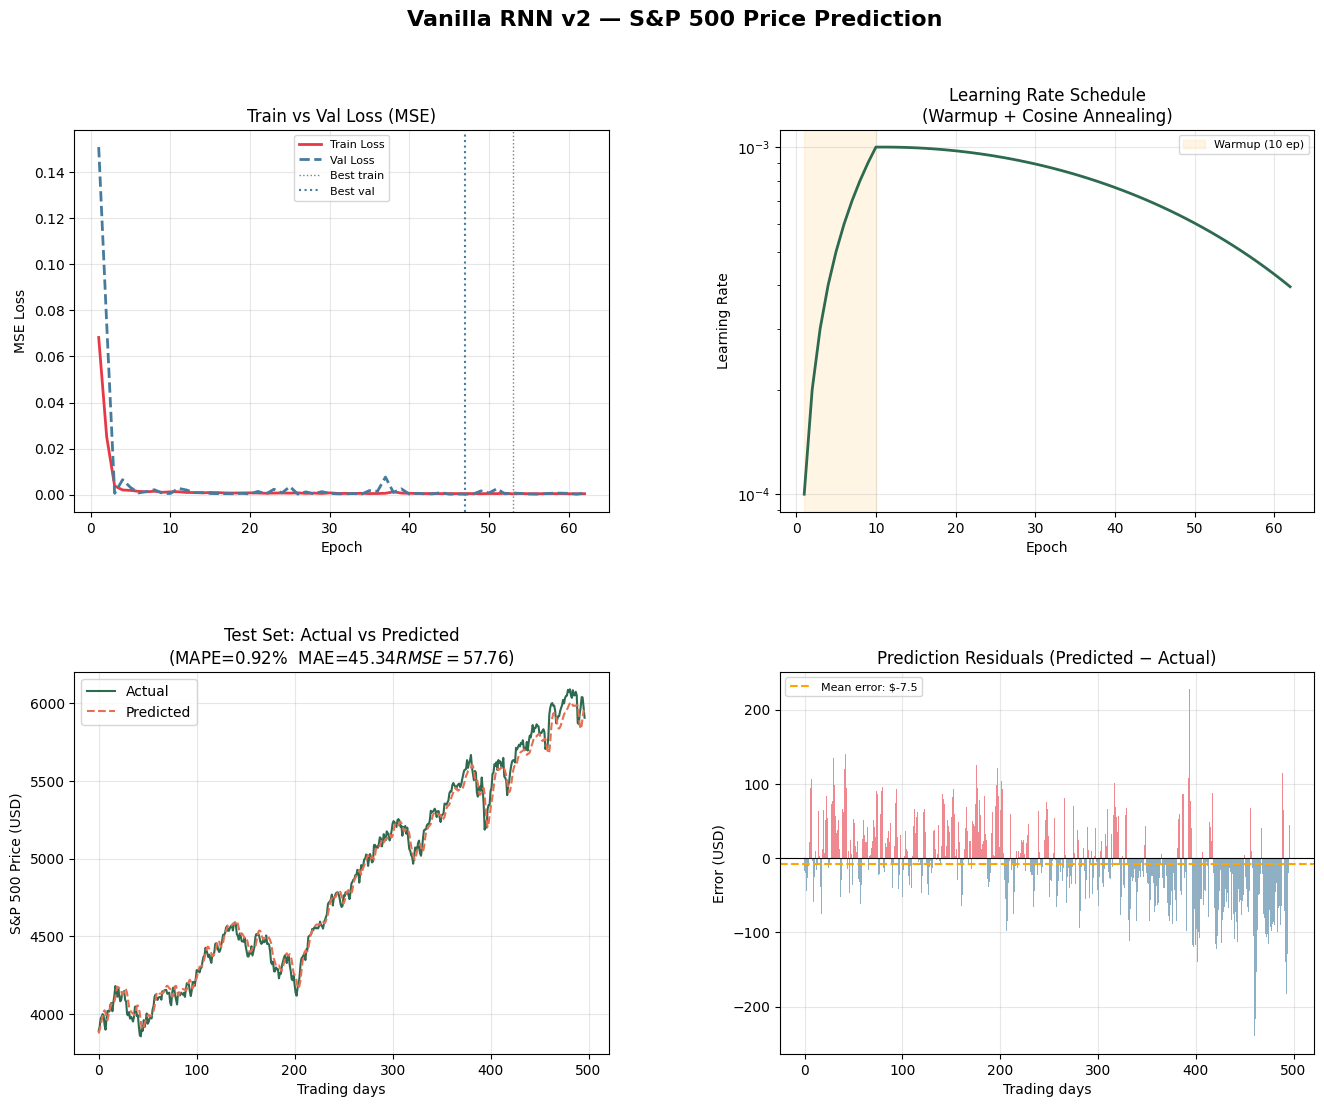

[INFO] Plot saved → rnn_v2_results.png


In [4]:
"""
=============================================================
  VANILLA RNN v2 — S&P 500 Price Prediction
=============================================================
"""

# ─────────────────────────────────────────────────────────────
# 1. IMPORTS
# ─────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ─────────────────────────────────────────────────────────────
# 2. REPRODUCIBILITY
# ─────────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ─────────────────────────────────────────────────────────────
# 3. HYPER-PARAMETERS
#    Key changes from v1:
#      HIDDEN_SIZE 64  → 128  (more capacity)
#      EPOCHS      60  → 100  (longer training)
#      WARMUP_EPOCHS   = 10   (new — linear LR ramp-up)
#      PATIENCE        = 15   (early stopping)
# ─────────────────────────────────────────────────────────────
TICKER        = "^GSPC"
START_DATE    = "2015-01-01"
END_DATE      = "2024-12-31"
SEQ_LEN       = 30
HIDDEN_SIZE   = 128
NUM_LAYERS    = 2
DROPOUT       = 0.2
BATCH_SIZE    = 64
EPOCHS        = 100
WARMUP_EPOCHS = 10
PATIENCE      = 15
LR            = 1e-3
TRAIN_RATIO   = 0.80
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Device: {DEVICE}")

# ─────────────────────────────────────────────────────────────
# 4. DATA LOADING  (auto_adjust=True explicit → no FutureWarning)
# ─────────────────────────────────────────────────────────────
raw = yf.download(TICKER, start=START_DATE, end=END_DATE,
                  auto_adjust=True, progress=False)

# Flatten MultiIndex if present (newer yfinance versions)
if hasattr(raw.columns, 'droplevel'):
    try:
        raw.columns = raw.columns.droplevel(1)
    except Exception:
        pass

prices = raw["Close"].dropna().values.astype(np.float32).reshape(-1, 1)
print(f"[INFO] {len(prices)} trading days loaded for {TICKER}")

# ─────────────────────────────────────────────────────────────
# 5. NORMALISATION
# ─────────────────────────────────────────────────────────────
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(prices)

# ─────────────────────────────────────────────────────────────
# 6. SEQUENCE CREATION
# ─────────────────────────────────────────────────────────────
def make_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])
        y.append(data[i + seq_len])
    return np.array(X, np.float32), np.array(y, np.float32)

X, y = make_sequences(scaled, SEQ_LEN)
print(f"[INFO] Sequences — X: {X.shape}, y: {y.shape}")

# ─────────────────────────────────────────────────────────────
# 7. TRAIN / TEST SPLIT
# ─────────────────────────────────────────────────────────────
split = int(len(X) * TRAIN_RATIO)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(f"[INFO] Train: {len(X_train)} | Test: {len(X_test)}")

# ─────────────────────────────────────────────────────────────
# 8. DATALOADERS
# ─────────────────────────────────────────────────────────────
def to_loader(X_np, y_np, bs, shuffle=True):
    ds = TensorDataset(torch.tensor(X_np), torch.tensor(y_np))
    return DataLoader(ds, batch_size=bs, shuffle=shuffle)

train_loader = to_loader(X_train, y_train, BATCH_SIZE, shuffle=True)
test_loader  = to_loader(X_test,  y_test,  BATCH_SIZE, shuffle=False)

# ─────────────────────────────────────────────────────────────
# 9. MODEL — Vanilla RNN (now with 128 hidden units)
# ─────────────────────────────────────────────────────────────
class VanillaRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.rnn = nn.RNN(
            input_size   = input_size,
            hidden_size  = hidden_size,
            num_layers   = num_layers,
            batch_first  = True,
            dropout      = dropout if num_layers > 1 else 0.0,
            nonlinearity = "tanh",
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)               # (batch, seq, hidden)
        out    = self.dropout(out[:, -1, :])  # last time-step
        return self.fc(out)                # (batch, 1)

model = VanillaRNN(1, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n[MODEL] {model}")
print(f"[INFO] Trainable parameters: {total_params:,}\n")

# ─────────────────────────────────────────────────────────────
# 10. LOSS, OPTIMISER & SCHEDULER
# ─────────────────────────────────────────────────────────────
criterion = nn.MSELoss()
optimiser = torch.optim.Adam(model.parameters(), lr=LR)

def warmup_cosine(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS          # linear ramp
    progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1 + np.cos(np.pi * progress))     # cosine decay

scheduler = torch.optim.lr_scheduler.LambdaLR(optimiser, lr_lambda=warmup_cosine)

# ─────────────────────────────────────────────────────────────
# 11. TRAINING LOOP with early stopping + best-model checkpoint
# ─────────────────────────────────────────────────────────────
train_losses, val_losses, lr_history = [], [], []
best_val_loss  = float("inf")
best_state     = None
patience_count = 0

for epoch in range(1, EPOCHS + 1):
    # ── Train phase ──
    model.train()
    ep_train = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimiser.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimiser.step()
        ep_train += loss.item() * xb.size(0)
    ep_train /= len(train_loader.dataset)

    # ── Val phase ──
    model.eval()
    ep_val = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            ep_val += criterion(model(xb), yb).item() * xb.size(0)
    ep_val /= len(test_loader.dataset)

    # ── Scheduler step (once per epoch for LambdaLR) ──
    current_lr = optimiser.param_groups[0]['lr']
    scheduler.step()

    train_losses.append(ep_train)
    val_losses.append(ep_val)
    lr_history.append(current_lr)

    # ── Best-model checkpoint ──
    if ep_val < best_val_loss:
        best_val_loss  = ep_val
        best_state     = {k: v.clone() for k, v in model.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1

    # ── Logging ──
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch [{epoch:>3}/{EPOCHS}]  "
              f"Train: {ep_train:.6f}  Val: {ep_val:.6f}  "
              f"LR: {current_lr:.2e}  "
              f"Patience: {patience_count}/{PATIENCE}")

    # ── Early stopping ──
    if patience_count >= PATIENCE:
        print(f"\n[EARLY STOP] No val improvement for {PATIENCE} epochs. "
              f"Stopping at epoch {epoch}.")
        break

# Restore best weights
model.load_state_dict(best_state)
print(f"\n[INFO] Best val loss: {best_val_loss:.6f} — best weights restored.")

# ─────────────────────────────────────────────────────────────
# 12. INFERENCE
# ─────────────────────────────────────────────────────────────
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        all_preds.append(model(xb.to(DEVICE)).cpu().numpy())
        all_true.append(yb.numpy())

pred_prices = scaler.inverse_transform(np.concatenate(all_preds))
true_prices = scaler.inverse_transform(np.concatenate(all_true))

# ─────────────────────────────────────────────────────────────
# 13. METRICS
# ─────────────────────────────────────────────────────────────
mae  = mean_absolute_error(true_prices, pred_prices)
rmse = np.sqrt(mean_squared_error(true_prices, pred_prices))
mape = np.mean(np.abs((true_prices - pred_prices) / true_prices)) * 100
print(f"\n[METRICS]")
print(f"  MAE  : ${mae:.2f}")
print(f"  RMSE : ${rmse:.2f}")
print(f"  MAPE : {mape:.2f}%")

# ─────────────────────────────────────────────────────────────
# 14. PLOTS — 4 panels
#     (a) Loss curves
#     (b) LR schedule
#     (c) Predictions vs actuals
#     (d) Residuals (prediction error over time)
# ─────────────────────────────────────────────────────────────
residuals = (pred_prices - true_prices).flatten()

fig = plt.figure(figsize=(16, 12))
fig.suptitle("Vanilla RNN v2 — S&P 500 Price Prediction", fontsize=16, fontweight="bold")
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)

# (a) Loss curves
ax1 = fig.add_subplot(gs[0, 0])
epochs_ran = len(train_losses)
ax1.plot(range(1, epochs_ran+1), train_losses, label="Train Loss", color="#e63946", lw=2)
ax1.plot(range(1, epochs_ran+1), val_losses,   label="Val Loss",   color="#457b9d", lw=2, ls="--")
ax1.axvline(train_losses.index(min(train_losses))+1, color="gray", ls=":", lw=1, label="Best train")
ax1.axvline(val_losses.index(min(val_losses))+1,     color="#457b9d", ls=":", lw=1.5, label="Best val")
ax1.set_title("Train vs Val Loss (MSE)")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("MSE Loss")
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

# (b) LR schedule — shows warmup + cosine decay clearly
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(range(1, epochs_ran+1), lr_history, color="#2d6a4f", lw=2)
ax2.axvspan(1, WARMUP_EPOCHS, alpha=0.1, color="orange", label=f"Warmup ({WARMUP_EPOCHS} ep)")
ax2.set_title("Learning Rate Schedule\n(Warmup + Cosine Annealing)")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Learning Rate")
ax2.set_yscale("log"); ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

# (c) Predictions vs actuals
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(true_prices, label="Actual",    color="#2d6a4f", lw=1.5)
ax3.plot(pred_prices, label="Predicted", color="#e76f51", lw=1.5, ls="--")
ax3.set_title(f"Test Set: Actual vs Predicted\n(MAPE={mape:.2f}%  MAE=${mae:.2f}  RMSE=${rmse:.2f})")
ax3.set_xlabel("Trading days"); ax3.set_ylabel("S&P 500 Price (USD)")
ax3.legend(); ax3.grid(True, alpha=0.3)

# (d) Residuals — should be centered on 0 with no clear trend
ax4 = fig.add_subplot(gs[1, 1])
ax4.bar(range(len(residuals)), residuals,
        color=["#e63946" if r > 0 else "#457b9d" for r in residuals],
        alpha=0.6, width=1.0)
ax4.axhline(0, color="black", lw=0.8)
ax4.axhline(residuals.mean(), color="orange", lw=1.5, ls="--",
            label=f"Mean error: ${residuals.mean():.1f}")
ax4.set_title("Prediction Residuals (Predicted − Actual)")
ax4.set_xlabel("Trading days"); ax4.set_ylabel("Error (USD)")
ax4.legend(fontsize=8); ax4.grid(True, alpha=0.3)

plt.savefig("rnn_v2_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("[INFO] Plot saved → rnn_v2_results.png")